# Phase 2 — EDA & Feature Engineering

Pulls from the postgres db built in phase 1, visualizes the churn drivers found in the SQL
analysis, and writes a model-ready feature table for phase 3.

Run after `02_transform.sql` has populated the db.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine, text

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 4.5)

# brew postgres on mac: socket connection, no password needed
db_url = os.environ.get("CHURN_DB_URL", "postgresql+psycopg2:///churn")
eng = create_engine(db_url)

Matplotlib is building the font cache; this may take a moment.


## Pull the data

One joined pull. Keeping the join in SQL instead of pandas merges -- the db already has the relationships.

In [2]:
q = '''
SELECT cu.customer_id,
       cu.age,
       cu.gender,
       p.plan_name,
       c.contract_name,
       c.months AS contract_months,
       s.tenure_months,
       s.total_spend,
       a.usage_frequency,
       a.support_calls,
       a.payment_delay_days,
       a.last_interaction_days,
       l.churned::INT AS churned
FROM customers cu
JOIN subscriptions s     ON s.customer_id = cu.customer_id
JOIN plan_types p        ON p.plan_type_id = s.plan_type_id
JOIN contract_types c    ON c.contract_type_id = s.contract_type_id
JOIN customer_activity a ON a.customer_id = cu.customer_id
JOIN churn_labels l      ON l.customer_id = cu.customer_id
'''
df = pd.read_sql(q, eng)
print(df.shape)
df.head()

(440832, 13)


,customer_id,age,gender,plan_name,contract_name,contract_months,tenure_months,total_spend,usage_frequency,support_calls,payment_delay_days,last_interaction_days,churned
0,10000,22,Male,Premium,Annual,12,1,933.0,13,6,30,11,1
1,100000,42,Female,Premium,Annual,12,60,310.0,8,4,16,18,1
2,100006,60,Male,Standard,Annual,12,48,261.0,17,2,29,25,1
3,100007,24,Female,Standard,Monthly,1,8,539.0,27,8,6,21,1
4,100014,54,Female,Premium,Monthly,1,52,799.0,18,0,28,27,1


In [3]:
# quick health check
print("churn rate:", round(df.churned.mean() * 100, 1), "%")
print("\nnulls per column:")
print(df.isna().sum())
df.describe().round(1)

churn rate: 56.7 %

nulls per column:
customer_id              0
age                      0
gender                   0
plan_name                0
contract_name            0
contract_months          0
tenure_months            0
total_spend              0
usage_frequency          0
support_calls            0
payment_delay_days       0
last_interaction_days    0
churned                  0
dtype: int64


,customer_id,age,contract_months,tenure_months,total_spend,usage_frequency,support_calls,payment_delay_days,last_interaction_days,churned
count,440832.0,440832.0,440832.0,440832.0,440832.0,440832.0,440832.0,440832.0,440832.0,440832.0
mean,225398.7,39.4,6.2,31.3,631.6,15.8,3.6,13.0,14.5,0.6
std,129531.9,12.4,4.8,17.3,240.8,8.6,3.1,8.3,8.6,0.5
min,2.0,18.0,1.0,1.0,100.0,1.0,0.0,0.0,1.0,0.0
25%,113621.8,29.0,3.0,16.0,480.0,9.0,1.0,6.0,7.0,0.0
50%,226125.5,39.0,3.0,32.0,661.0,16.0,3.0,12.0,14.0,1.0
75%,337739.2,48.0,12.0,46.0,830.0,23.0,6.0,19.0,22.0,1.0
max,449999.0,65.0,12.0,60.0,1000.0,30.0,10.0,30.0,30.0,1.0


## Distributions

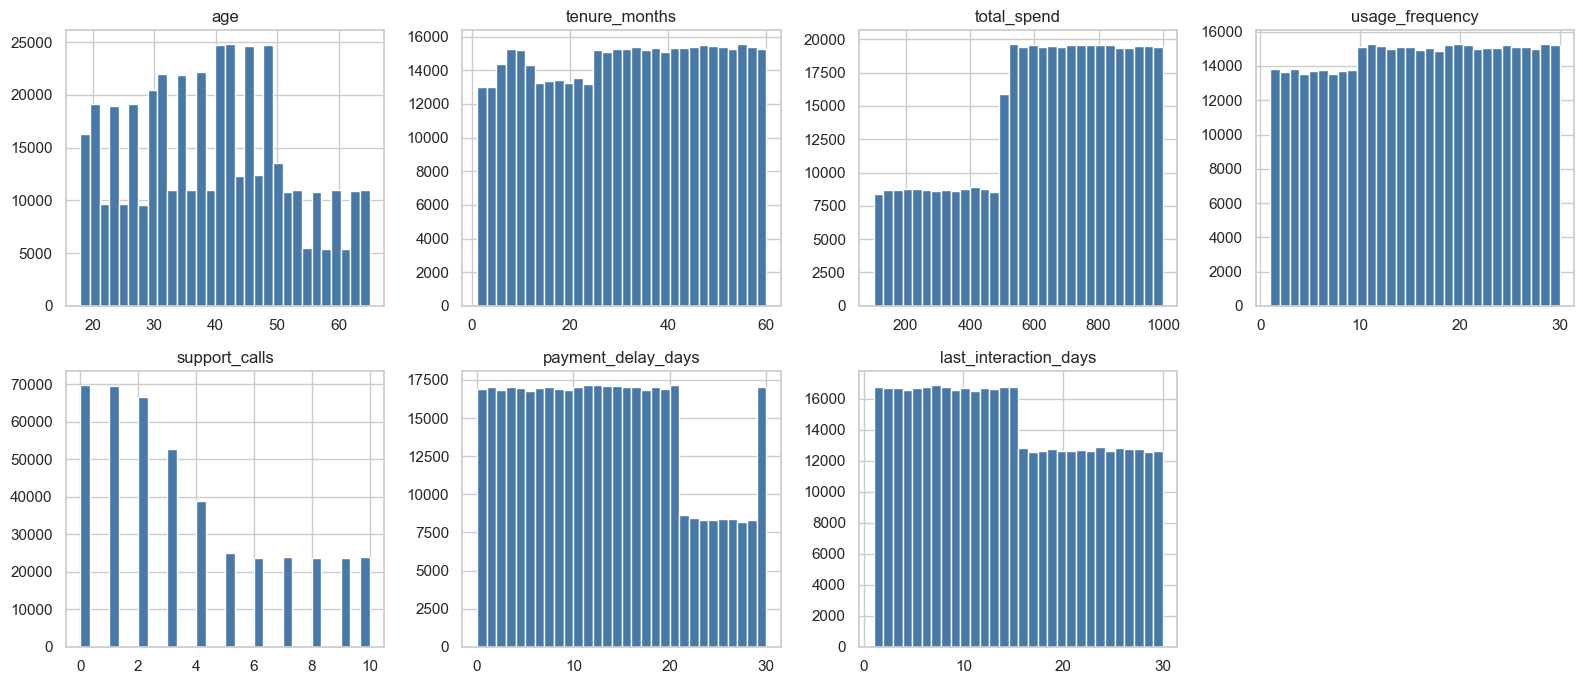

In [4]:
num_cols = ["age", "tenure_months", "total_spend", "usage_frequency",
            "support_calls", "payment_delay_days", "last_interaction_days"]
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, col in zip(axes.flat, num_cols):
    ax.hist(df[col], bins=30, color="#4878a8", edgecolor="white")
    ax.set_title(col)
axes.flat[-1].axis("off")
plt.tight_layout()
plt.show()
# takeaway: distributions are near-uniform -- another tell this data is synthetic

## Support calls — the strongest signal

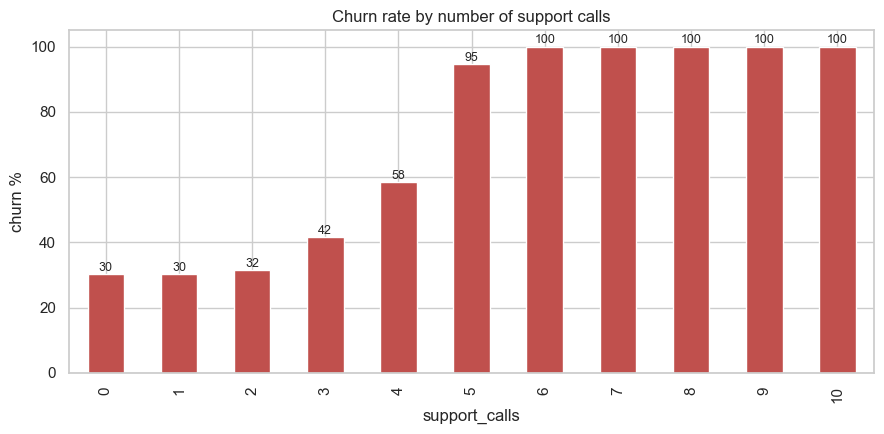

In [5]:
sc = df.groupby("support_calls").churned.agg(["mean", "size"])
ax = (sc["mean"] * 100).plot(kind="bar", color="#c0504d", edgecolor="white")
ax.set_ylabel("churn %")
ax.set_title("Churn rate by number of support calls")
for i, v in enumerate(sc["mean"] * 100):
    ax.text(i, v + 1, f"{v:.0f}", ha="center", fontsize=9)
plt.tight_layout()
plt.show()
# takeaway: flat ~30% through 2 calls, elbow at 3-4, near-total churn at 5+.
# 5 calls is the intervention threshold

## Contract type

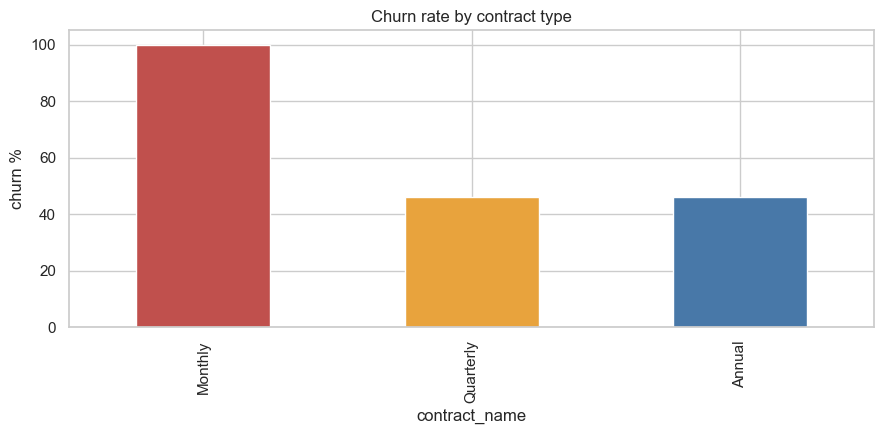

In [6]:
ct = df.groupby("contract_name").churned.mean().mul(100).reindex(["Monthly", "Quarterly", "Annual"])
ax = ct.plot(kind="bar", color=["#c0504d", "#e8a33d", "#4878a8"], edgecolor="white")
ax.set_ylabel("churn %")
ax.set_title("Churn rate by contract type")
plt.tight_layout()
plt.show()
# takeaway: monthly churns at 100% -- a hard-coded rule in the synthetic data.
# the model will lean on this, which is why phase 3 also trains a behavioral-only variant

## The low-spend cliff (within contract)

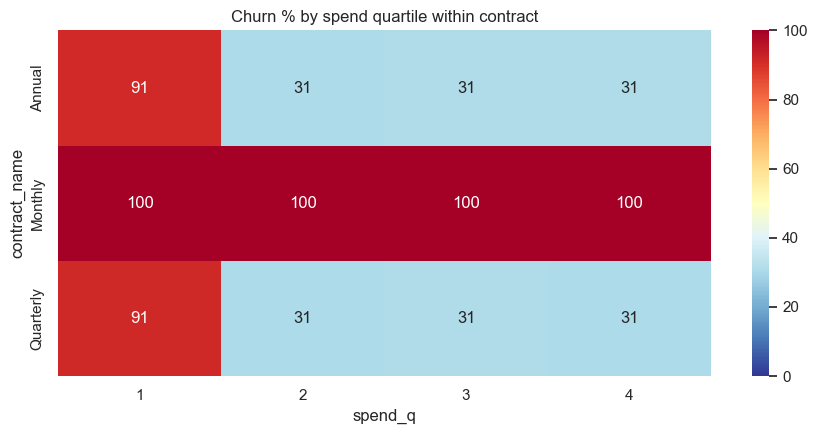

In [7]:
df["spend_q"] = df.groupby("contract_name").total_spend.transform(
    lambda s: pd.qcut(s, 4, labels=[1, 2, 3, 4]))
piv = df.pivot_table(index="contract_name", columns="spend_q",
                     values="churned", aggfunc="mean", observed=True) * 100
ax = sns.heatmap(piv, annot=True, fmt=".0f", cmap="RdYlBu_r", vmin=0, vmax=100)
ax.set_title("Churn % by spend quartile within contract")
plt.tight_layout()
plt.show()
# takeaway: bottom spend quartile churns ~91% in quarterly/annual vs ~31% elsewhere.
# cheap customers leave, but only in the longer contracts (monthly is already 100%)

## Demographics

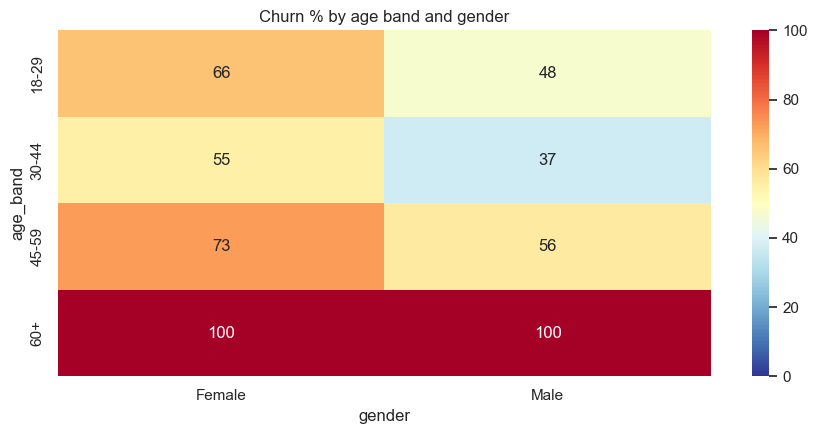

In [8]:
df["age_band"] = pd.cut(df.age, [17, 29, 44, 59, 200],
                        labels=["18-29", "30-44", "45-59", "60+"])
piv = df.pivot_table(index="age_band", columns="gender",
                     values="churned", aggfunc="mean", observed=True) * 100
ax = sns.heatmap(piv, annot=True, fmt=".0f", cmap="RdYlBu_r", vmin=0, vmax=100)
ax.set_title("Churn % by age band and gender")
plt.tight_layout()
plt.show()
# takeaway: 60+ churns at exactly 100% for both genders (another synthetic rule),
# and women churn ~15-20pts above men in every band

## Correlations

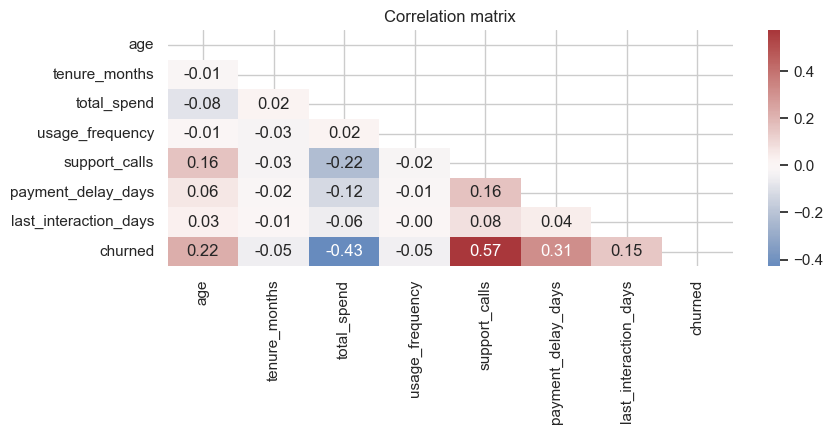

In [9]:
corr = df[num_cols + ["churned"]].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="vlag", center=0)
plt.title("Correlation matrix")
plt.tight_layout()
plt.show()
# takeaway: support_calls and payment_delay carry most of the linear signal

## Caveat for the writeup

Several patterns above are deterministic (100% churn for monthly contracts, 6+ support calls,
and age 60+), which confirms the dataset is synthetic. Models trained on the full feature set
will score near-perfectly. Phase 3 leans into this: report the easy score, then train a
behavioral-features-only model and treat the classification threshold as a business decision.

## Feature engineering

Builds the model-ready table and writes it back to postgres + parquet.

In [10]:
ft = df.copy()

# behavioral flags from the EDA
ft["high_support"] = (ft.support_calls >= 5).astype(int)
ft["long_delay"] = (ft.payment_delay_days >= 20).astype(int)
ft["spend_per_month"] = (ft.total_spend / ft.tenure_months.clip(lower=1)).round(2)
ft["inactive"] = (ft.last_interaction_days >= 20).astype(int)

# encode the categoricals. contract as ordinal months (already have it),
# plan + gender as one-hots
ft = pd.get_dummies(ft, columns=["plan_name", "gender"], drop_first=True, dtype=int)

drop = ["contract_name", "spend_q", "age_band"]  # redundant with contract_months / engineered cols
ft = ft.drop(columns=drop)
print(ft.shape)
ft.head()

(440832, 17)


,customer_id,age,contract_months,tenure_months,total_spend,usage_frequency,support_calls,payment_delay_days,last_interaction_days,churned,high_support,long_delay,spend_per_month,inactive,plan_name_Premium,plan_name_Standard,gender_Male
0,10000,22,12,1,933.0,13,6,30,11,1,1,1,933.00,0,1,0,1
1,100000,42,12,60,310.0,8,4,16,18,1,0,0,5.17,0,1,0,0
2,100006,60,12,48,261.0,17,2,29,25,1,0,1,5.44,1,0,1,1
3,100007,24,1,8,539.0,27,8,6,21,1,1,0,67.38,1,0,1,0
4,100014,54,1,52,799.0,18,0,28,27,1,0,1,15.37,1,1,0,0


In [11]:
# persist for phase 3: postgres table for the dashboard, parquet for the model
from pathlib import Path
root = Path.cwd() if (Path.cwd() / "sql").exists() else Path.cwd().parent  # works from root or notebooks/
out = root / "data" / "features.parquet"
out.parent.mkdir(exist_ok=True)

ft.to_sql("features", eng, if_exists="replace", index=False, chunksize=20000)
ft.to_parquet(out, index=False)
print("wrote", len(ft), "rows to features table +", out)

wrote 440832 rows to features table + /Users/arthurthach/Desktop/Customer Retention Analysis /churn-project/data/features.parquet
